<a href="https://colab.research.google.com/github/PatrickPasolini/water_potability_classification/blob/main/water_potability_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water Potability
link dataset : https://raw.githubusercontent.com/PatrickPasolini/water_potability_classification/refs/heads/main/data/water_potability.csv


##Import

In [42]:
!pip install optuna

In [43]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (ExtraTreesClassifier, BaggingClassifier,
                              AdaBoostClassifier, StackingClassifier)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import (SVC, LinearSVC)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV)

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
import optuna
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import cross_validate


## Caricamento dati

In [44]:
DATA_PATH = "https://raw.githubusercontent.com/PatrickPasolini/water_potability_classification/refs/heads/main/data/water_potability.csv"

In [45]:
df = pd.read_csv(DATA_PATH)

In [46]:
# Costanti
TARGET = 'Potability'
RANDOM_STATE = 42
TRAIN_SIZE = 0.75

## Controlli di integrità e pulizia (pre-split)

Operazioni eseguite sull'intero dataset **prima** dello split perché sono deterministiche e non stimano parametri dai dati.

In [47]:
print("Tipi di dato:")
print(df.dtypes)

print("\nValori distinti per colonna:")
print(df.nunique())

print("\nColonne costanti (varianza nulla):",
      df.columns[df.nunique() <= 1].tolist() or "nessuna")
print("Colonne duplicate:", df.T.duplicated().any())

Tipi di dato:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Valori distinti per colonna:
ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64

Colonne costanti (varianza nulla): nessuna
Colonne duplicate: False


### Duplicati

In [48]:
print("Numero di istanze:", len(df))
df = df.drop_duplicates()
print("Numero di istanze senza duplicati:", len(df))
# Si ossserva che non ci sono duplicati

Numero di istanze: 3276
Numero di istanze senza duplicati: 3276


In [49]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET]

# Split del dataset (stratificato per mantenere la proporzione 60/40 in entrambi i set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} istanze | Test: {X_test.shape[0]} istanze")
print(f"\nProporzione classi (train):\n{y_train.value_counts(normalize=True).round(2)}")
print(f"\nProporzione classi (test):\n{y_test.value_counts(normalize=True).round(2)}")

Train: 2457 istanze | Test: 819 istanze

Proporzione classi (train):
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Proporzione classi (test):
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


In [50]:
# Dataframe di solo training
train_df = X_train.copy()
train_df[TARGET] = y_train

## Analisi esplorativa

### Distribuzione delle feature


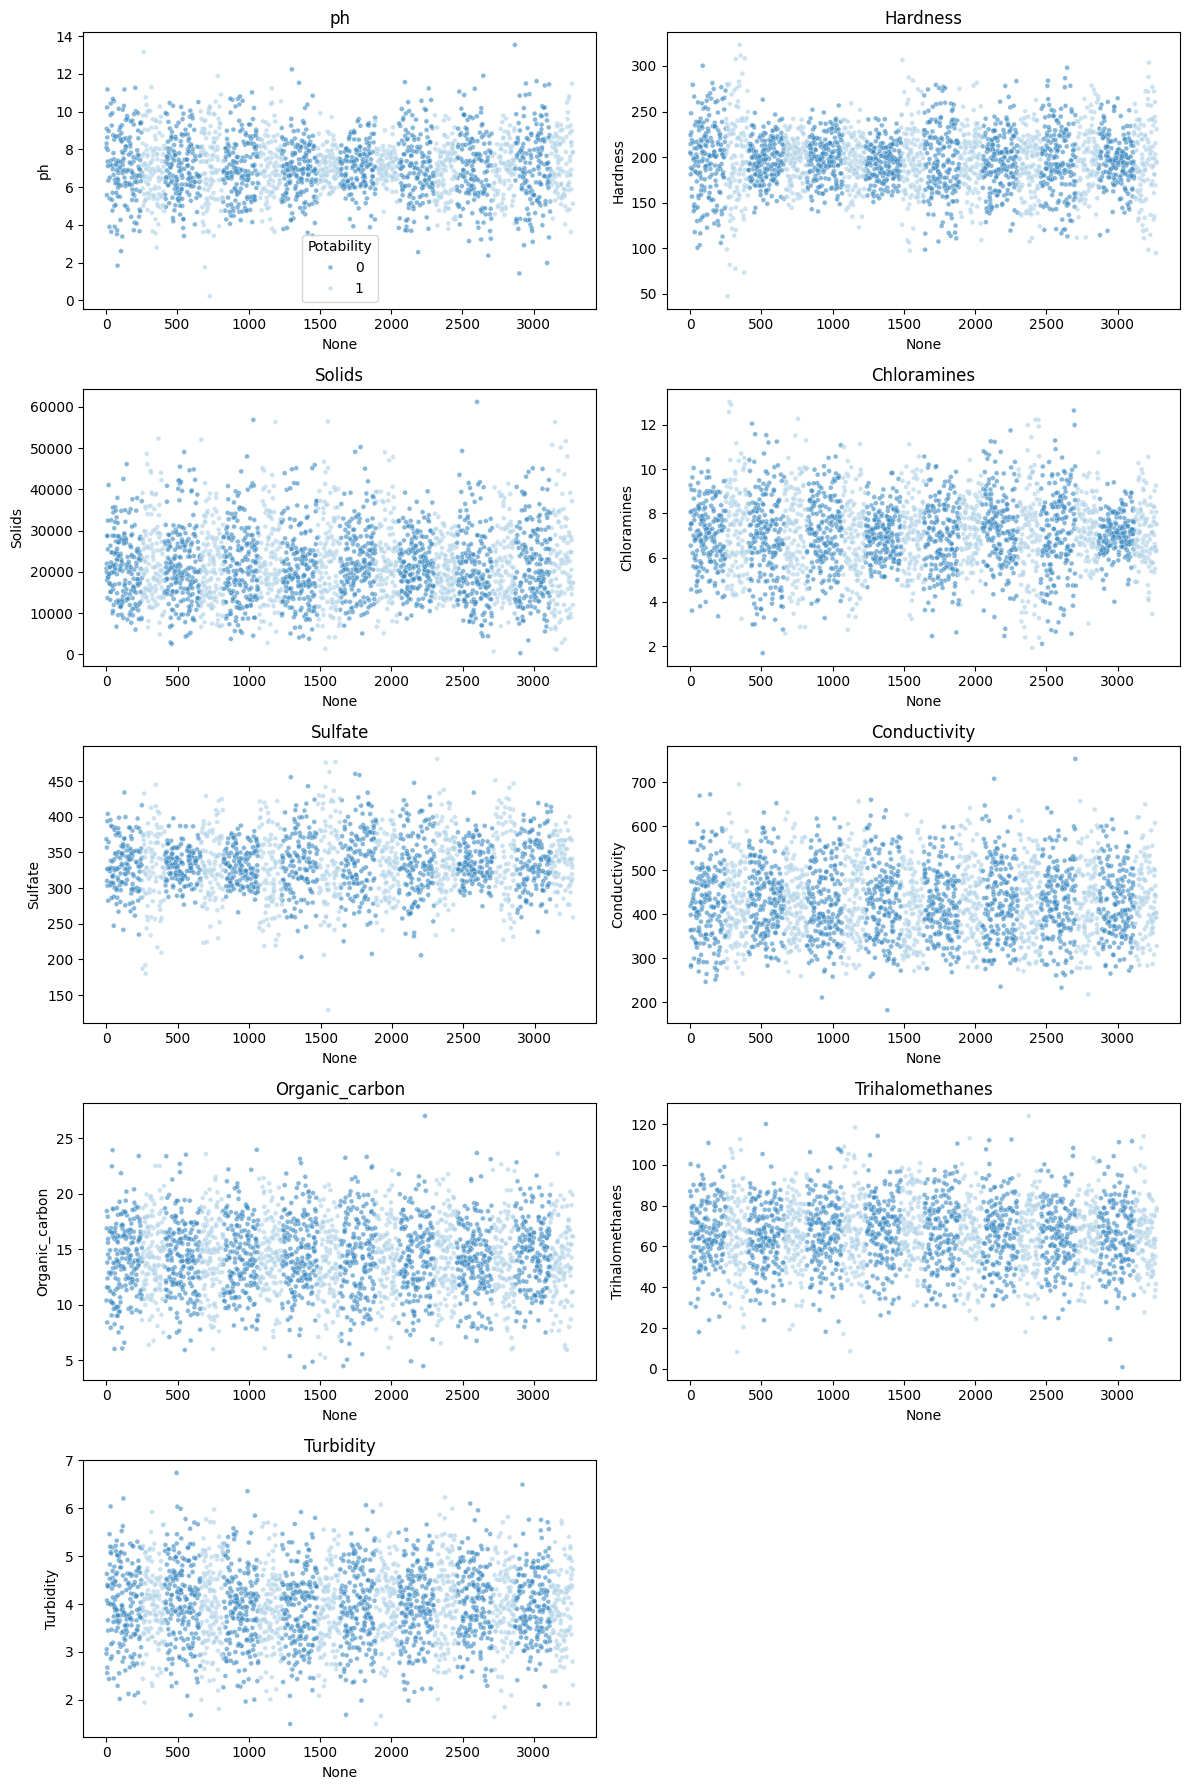

In [51]:
features = X_train.columns
fig, axs = plt.subplots(5, 2, figsize=(12, 18))
axs = axs.flatten()

for i, col in enumerate(features):
    sns.scatterplot(data=train_df, x=train_df.index, y=col, hue='Potability',
                    ax=axs[i], palette='Blues_r', s=12, alpha=0.6, legend=(i == 0))
    axs[i].set_title(col)

# Senza divisione per classe
#for i, col in enumerate(features):
#    axs[i].scatter(df.index, df[col], color=BLUE, s=10, alpha=0.6)
#    axs[i].set_title(col)

# nasconde l'ultimo subplot vuoto (9 feature su griglia 5x2)
axs[-1].set_visible(False)

plt.tight_layout()
plt.show()

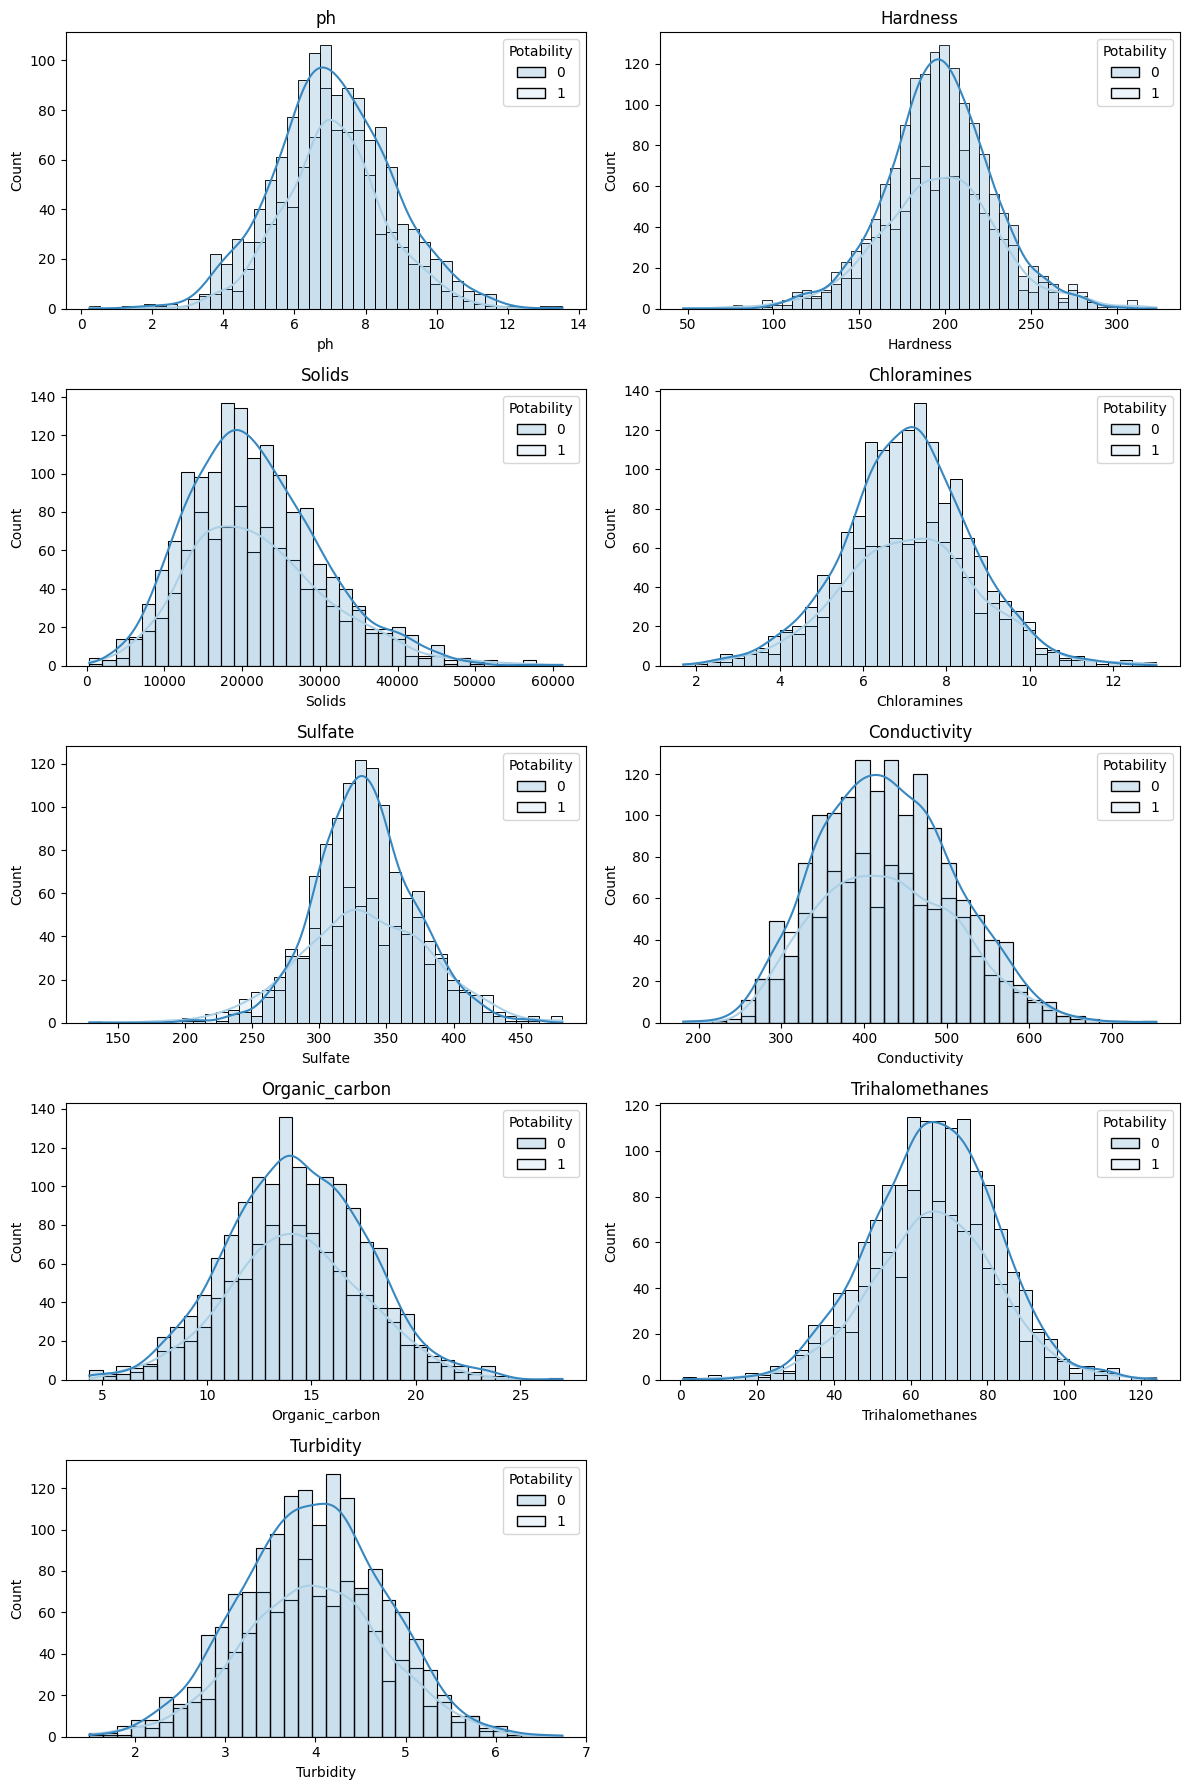

In [52]:
features = X_train.columns
fig, axs = plt.subplots(5, 2, figsize=(12, 18))
axs = axs.flatten()

for i, col in enumerate(features):
    sns.histplot(data=train_df, x=col, hue=TARGET, kde=True,
                 ax=axs[i], palette='Blues_r', alpha=0.2)
    axs[i].set_title(col)

# nasconde l'ultimo subplot vuoto (9 feature su griglia 5x2)
axs[-1].set_visible(False)

plt.tight_layout()
plt.show()

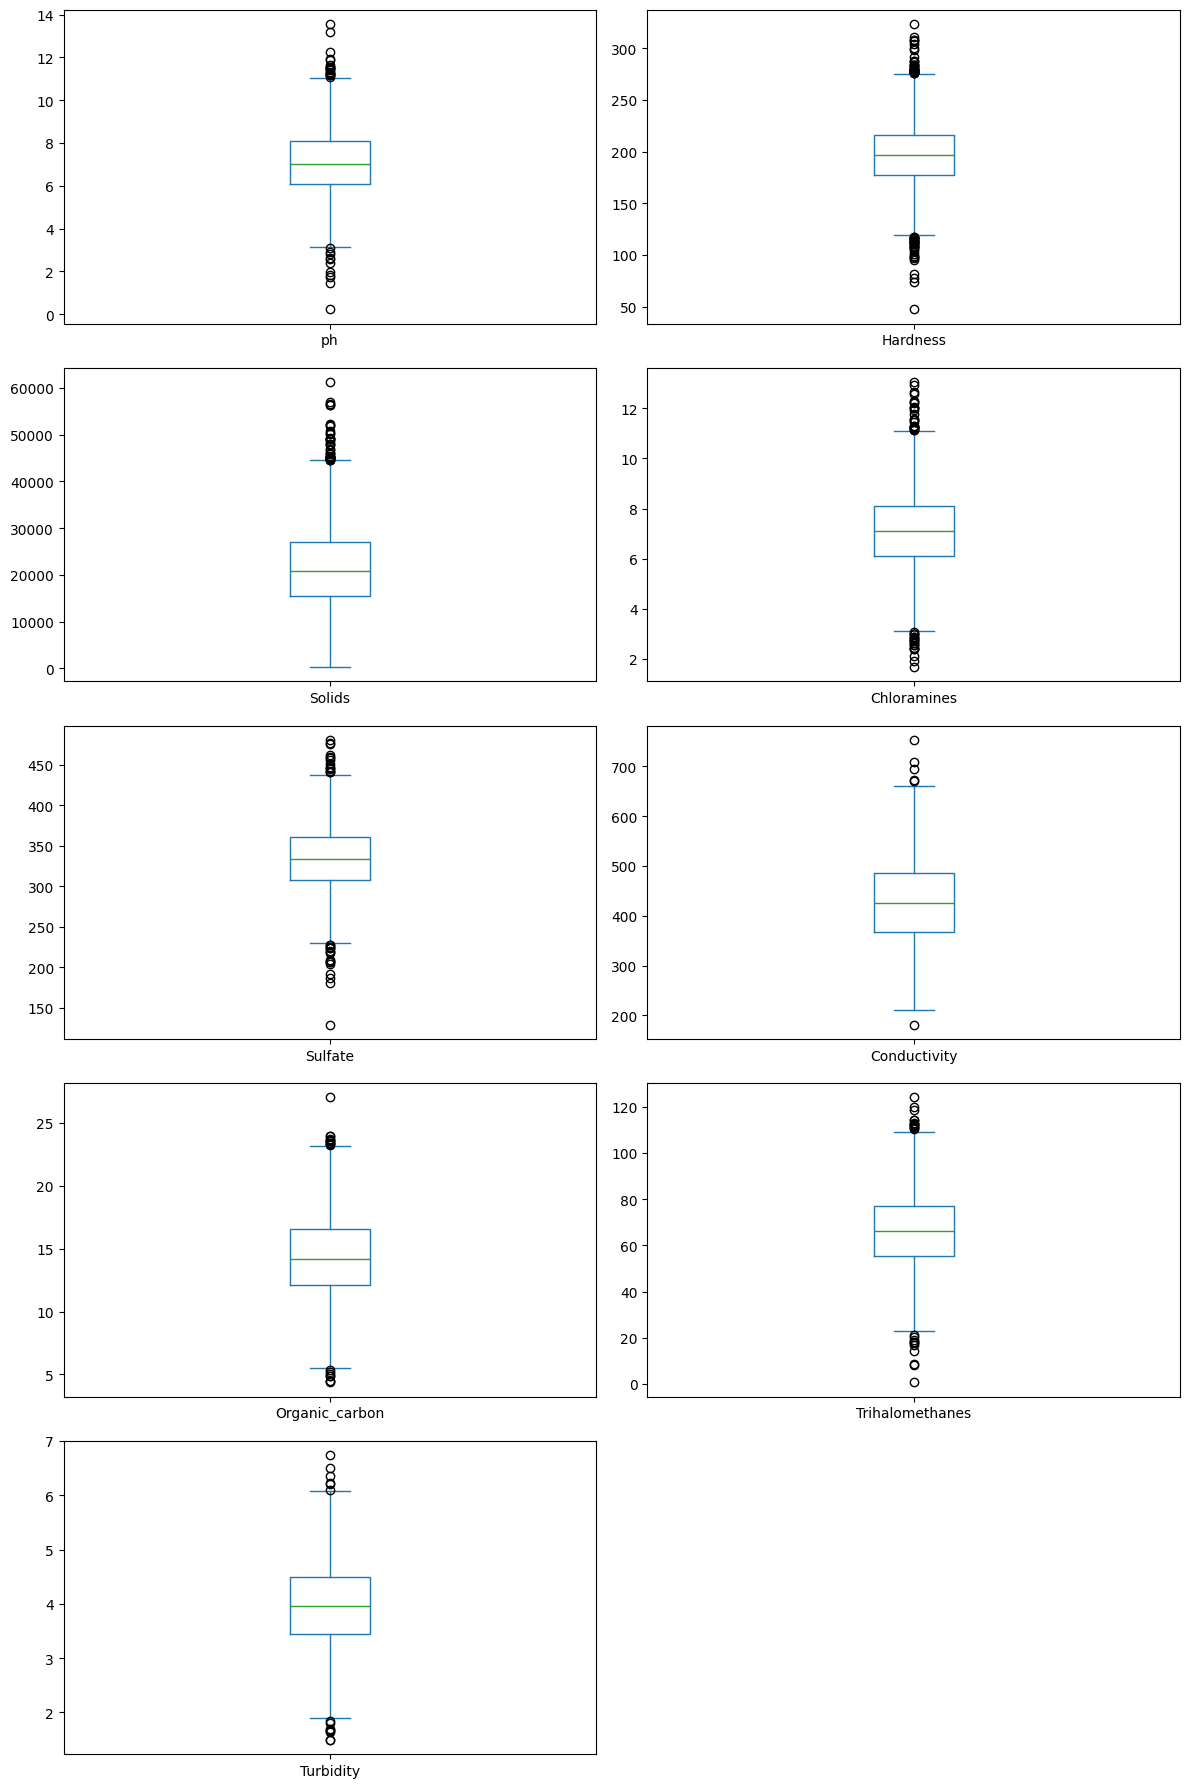

In [53]:
X_train.plot(kind='box', subplots=True, layout=(5,2),
             figsize=(12,18), sharex=False, sharey=False)
plt.tight_layout(); plt.show()

Nessuna feature presenta valori impossibili: il "pH" resta in [0,14] e non esistono concentrazioni negative. L'unica feature con valori realisticamente estremi ma non impossibili è "Solid" ma scelgo di manterere comunque questi dati perchè perderei molte istanze e introdurrei un sblinanciamento tra le classi.

### Correlazioni

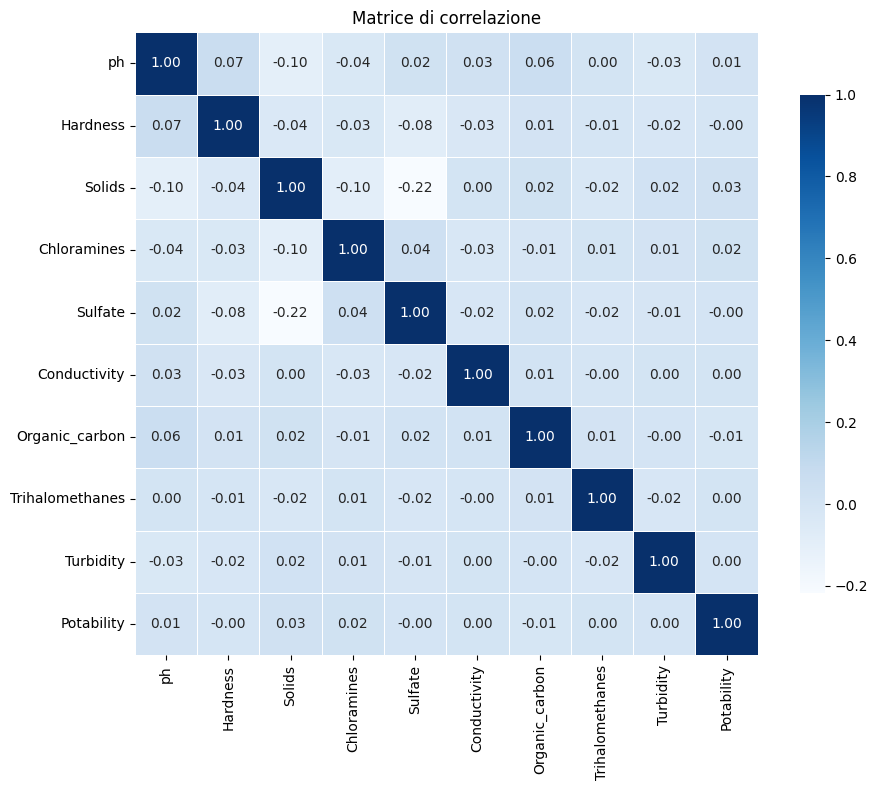

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap="Blues", square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

**Osservazioni:**
- Le feature sono tra loro **scarsamente correlate**  => nessuna feature viene
  rimossa per collinearità.
- La correlazione **feature–target è praticamente nulla** => nessuna variabile, presa singolarmente, è linearmente associata alla potabilità.

Ne consegue che l'eventuale segnale predittivo risiede in **interazioni non
lineari** tra le feature.

Questo motiva la scelta di modelli capaci di catturare interazioni non lienari:  SVM con kernel, Random Forest, Extra Trees, Gradient Boosting anziché modelli
lineari e si evita una feature selection basata sulla sola correlazione, che scarterebbe variabili potenzialmente utili in combinazione tra loro.

## Data cleaning

### Missing values

In [55]:
train_df.isnull().sum()

,0
ph,366
Hardness,0
Solids,0
Chloramines,0
Sulfate,591
Conductivity,0
Organic_carbon,0
Trihalomethanes,125
Turbidity,0
Potability,0


/tmp/ipykernel_790/191035084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Blues")


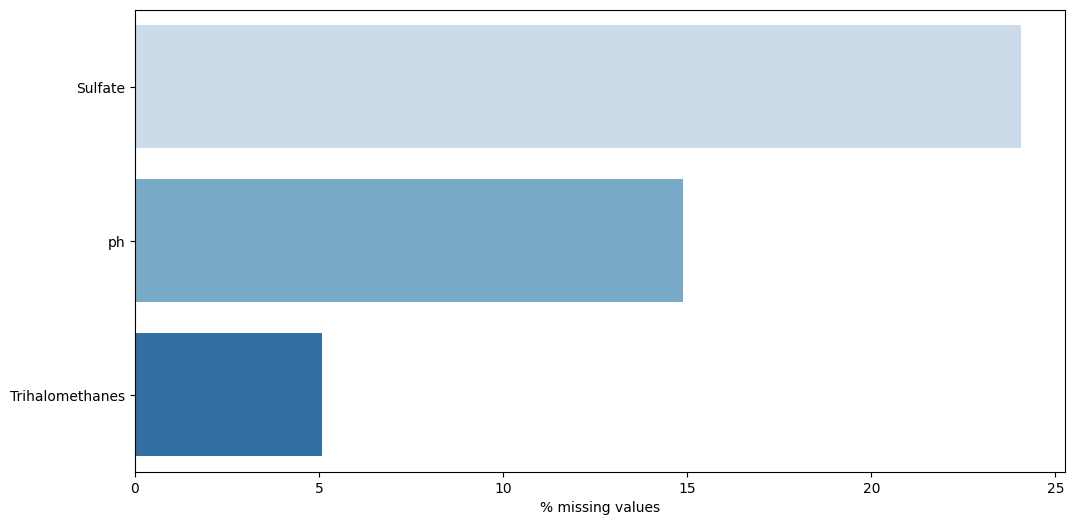

In [56]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = missing / len(train_df) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="Blues")
plt.xlabel("% missing values")
plt.ylabel("")
plt.show()

<Axes: >

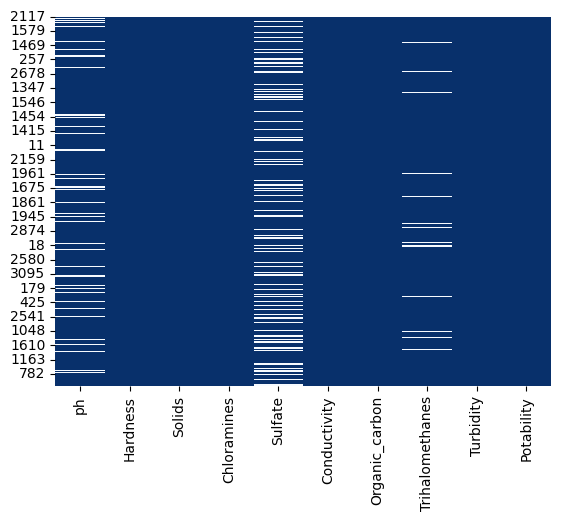

In [57]:
sns.heatmap(train_df.isnull(), cmap="Blues_r", cbar=False)

Notiamo che sono solo 3 le features con dei missing values: Sulfate, ph e Trihalomethanes

In [58]:
train_df.groupby(TARGET)[['ph','Sulfate','Trihalomethanes']].median()
# le mediane calcolate separate per classe sono quasi identiche
# scelgo di non imputare usando le statistiche per classe perchè significherebbe usare la classe nel preprocessing, informazione non disponibile per le nuove istanze.
# Inoltre dato che i valori mediani sono quasi identici l'imputazione per classe non porterebbe alcun vantaggio.

,ph,Sulfate,Trihalomethanes
Potability,,,
0,7.009923,333.076588,66.188642
1,7.064789,333.374481,66.678214


In [59]:
train_df.groupby('Potability')[['ph','Sulfate','Trihalomethanes']].apply(lambda x: x.isnull().mean()*100).round(1)
# i dati mancanti sono distribuiti in modo abbastanza uniforme, sono leggermente di più quelli di classe 0

,ph,Sulfate,Trihalomethanes
Potability,,,
0,15.5,24.6,5.7
1,13.9,23.2,4.1


**Strategia di imputazione**

I valori mancanti vengono imputati con la **mediana** di ciascuna colonna,
calcolata su tutte le righe senza distinzione di classe, ovvero con mediana globale.
La mediana è preferita alla media perché più robusta rispetto agli outlier.

L'imputazione non viene applicata ora sul dataframe, ma inserita come primo
step della pipeline di ciascun modello
così da essere ricalcolata solo sul training di ogni fold durante la
cross-validation, evitando il data leakage.

## Bilanciamento delle classi

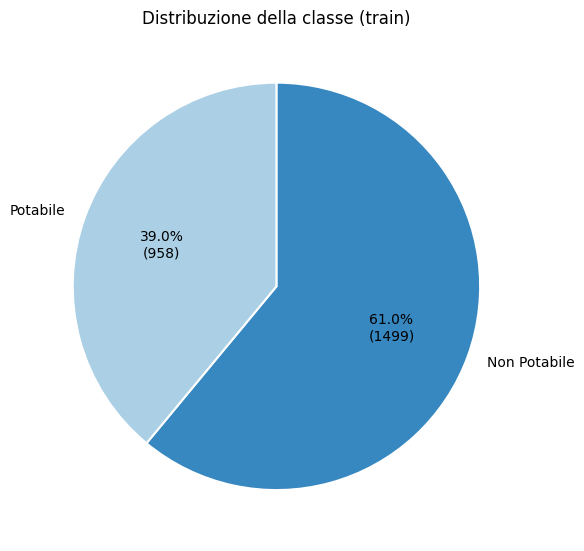

In [60]:
# grafico a torta distribuzione della classe
counts = y_train.value_counts().sort_index()  # 0 = Non Potabile, 1 = Potabile

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["Non Potabile", "Potabile"],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*counts.sum()))})",
    colors=sns.color_palette('Blues_r', n_colors=2),
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribuzione della classe (train)')
plt.tight_layout()
plt.show()

In [61]:
# Distribuzione della classe
print(y_train.value_counts(normalize=True).round(2))

ratio = y_train.value_counts().max() / y_train.value_counts().min()
print(f"\nRapporto di sbilanciamento: {ratio:.2f}:1")

Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Rapporto di sbilanciamento: 1.56:1


## Modelli

### Utility

In [62]:
def run_grid_search(pipe, param_grid, scoring='f1', n_splits=5):
    cv = StratifiedKFold(
           n_splits=n_splits,
           shuffle=True,
           random_state=RANDOM_STATE)

    grid = GridSearchCV(
           pipe,
           param_grid,
           scoring=scoring,
           cv=cv,
           n_jobs=-1)

    grid.fit(X_train, y_train)

    print(f"Combinazioni provate: {len(grid.cv_results_['params'])}")
    print(f"Miglior {scoring} (CV): {grid.best_score_:.3f}")
    print("Migliori parametri:")
    for k, v in grid.best_params_.items():
        print(f"  {k}: {v}")
    return grid

In [63]:
tuned_models = {}   # nome -> {'cv_f1', 'train_f1', 'predict'}

def registra_e_confronta(nome, estimator=None, cv_f1=None, predict_fn=None):
    """Registra un modello tunato e lo confronta con la sua baseline (sempre su CV, mai sul test)."""
    if predict_fn is None:
        predict_fn = estimator.predict
    train_f1 = f1_score(y_train, predict_fn(X_train), average='macro')
    tuned_models[nome] = {'cv_f1': cv_f1, 'train_f1': train_f1, 'predict': predict_fn}

    riga = f"[{nome}]  CV_F1 (tuned): {cv_f1:.3f}   Train_F1: {train_f1:.3f}"
    if nome in results_df['Model'].values:
        base = results_df.set_index('Model').loc[nome]
        riga += f"   (baseline non tunata -> CV {base['CV_F1']:.3f})"
    print(riga)


### Confronto preliminare dei modelli

Tutti i modelli classici con **configurazione di default** (imputazione mediana e  **RobustScaler** per i modelli sensibili alla scala).

Per ognuno calcoliamo l'**F1 macro** in tre versioni:

- **CV_F1** — cross-validation a 5 fold sul training: fa la media degli F1 dulle k fold usate come validation set.
- **Train_F1** — solo diagnostica: il divario rispetto a CV_F1 misura l'overfitting (es. gli alberi non potati arrivano a 1.0), non lo uso per selezionare.

La **rete neurale** non entra in questo screening: con i default non darebbe performance significative e in CV è costosa. Viene ottimizzata a parte con Optuna  e inserita nel confronto finale insieme ai modelli classici tunati.

L'ottimizzazione degli iperparametri viene fatta sui modelli con `CV_F1` più alta.


In [64]:
# Stacking = base learner ad albero + meta modello
stacking_clf = StackingClassifier(
    estimators=[('rf', RandomForestClassifier(random_state=RANDOM_STATE)),
                ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE))],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5)

# modelli sensibili alla scala => RobustScaler
SCALE = {'MLP (sklearn)', 'SVM lineare', 'SVM polinomiale', 'SVM RBF'}

models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':     RandomForestClassifier(random_state=RANDOM_STATE),
    'Extra Trees':       ExtraTreesClassifier(random_state=RANDOM_STATE),
    'MLP (sklearn)':     MLPClassifier(random_state=RANDOM_STATE, max_iter=500),
    'SVM lineare':       SVC(kernel='linear', random_state=RANDOM_STATE),
    'SVM polinomiale':   SVC(kernel='poly',   random_state=RANDOM_STATE),
    'SVM RBF':           SVC(kernel='rbf',    random_state=RANDOM_STATE),
    'Bagging':           BaggingClassifier(random_state=RANDOM_STATE),
    'AdaBoost':          AdaBoostClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost':           XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    'Stacking':          stacking_clf,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if name in SCALE:
        steps.append(('scaler', RobustScaler()))
    steps.append(('clf', model))
    pipe = Pipeline(steps)

    # CV: F1 macro (selezione) e accuracy in un'unica cross-validation sul training
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=['f1_macro', 'accuracy'])

    # fit sull'intero training -> metriche su train (diagnostica overfitting)
    pipe.fit(X_train, y_train)
    ytr_pred = pipe.predict(X_train)

    results.append({
        'Model':     name,
        'CV_F1':     scores['test_f1_macro'].mean(),
        'CV_Acc':    scores['test_accuracy'].mean(),
        'Train_F1':  f1_score(y_train, ytr_pred, average='macro'),
        'Train_Acc': accuracy_score(y_train, ytr_pred)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [65]:
col_order = ['Model', 'CV_F1', 'CV_Acc', 'Train_F1', 'Train_Acc']
results_df = (pd.DataFrame(results)[col_order]
              .sort_values('CV_F1', ascending=False)
              .reset_index(drop=True))

display(results_df.round(3))

,Model,CV_F1,CV_Acc,Train_F1,Train_Acc
0,MLP (sklearn),0.634,0.668,0.805,0.821
1,Random Forest,0.604,0.665,1.000,1.000
2,XGBoost,0.603,0.641,0.999,0.999
3,Stacking,0.602,0.670,1.000,1.000
4,SVM RBF,0.601,0.676,0.679,0.737
5,Bagging,0.593,0.647,0.983,0.984
6,Extra Trees,0.591,0.665,1.000,1.000
7,Decision Tree,0.573,0.591,1.000,1.000
8,Gradient Boosting,0.558,0.641,0.680,0.742
9,AdaBoost,0.465,0.613,0.468,0.630


/tmp/ipykernel_790/1551820601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='CV_F1', y='Model', palette='Blues_r')


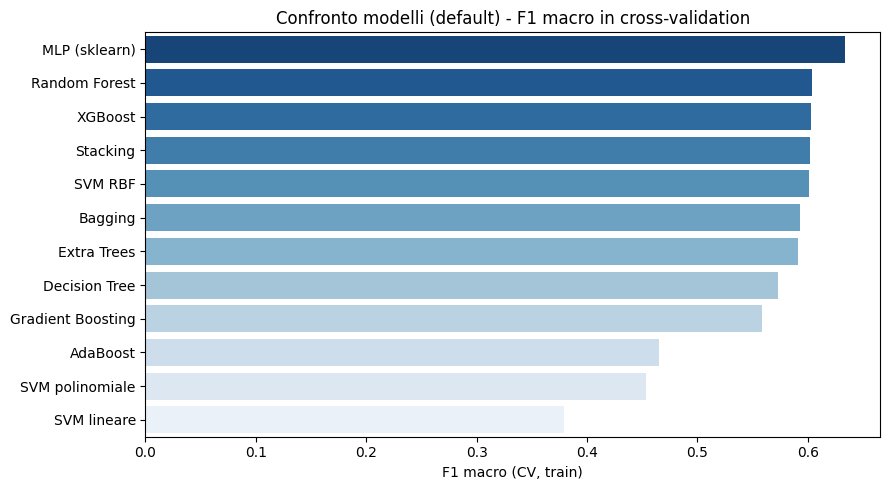

In [66]:
# Barplot sulla metrica di selezione (CV F1 macro)
plot_df = results_df.sort_values('CV_F1', ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='CV_F1', y='Model', palette='Blues_r')
plt.title('Confronto modelli (default) - F1 macro in cross-validation')
plt.xlabel('F1 macro (CV, train)'); plt.ylabel('')
plt.tight_layout(); plt.show()


## Ottimizzazione degli iperparametri

In [67]:
BILANCIAMENTO = True
print(f"Bilanciamento classi: {'ATTIVO' if BILANCIAMENTO else 'DISATTIVO'}")


Bilanciamento classi: ATTIVO


### Random Forest


In [69]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1,
        class_weight='balanced' if BILANCIAMENTO else None))
])

param_grid_rf = {
    'clf__n_estimators': [200, 400, 600],
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth':        [None, 15, 20],
    'clf__min_samples_leaf': [3, 5, 8],
    'clf__max_features':     [0.5, 0.7, 'sqrt'],
}

rf_grid = run_grid_search(rf_pipe, param_grid_rf, scoring='f1_macro')


Combinazioni provate: 162
Miglior f1_macro (CV): 0.632
Migliori parametri:
  clf__criterion: gini
  clf__max_depth: None
  clf__max_features: 0.7
  clf__min_samples_leaf: 8
  clf__n_estimators: 200


In [70]:
best_rf = rf_grid.best_estimator_
registra_e_confronta('Random Forest', best_rf, cv_f1=rf_grid.best_score_)


[Random Forest]  CV_F1 (tuned): 0.632   Train_F1: 0.939   (baseline non tunata -> CV 0.604)


=== Random Forest | bilanciamento: ON ===
              precision    recall  f1-score   support

Non Potabile      0.694     0.814     0.749       499
    Potabile      0.603     0.441     0.509       320

    accuracy                          0.668       819
   macro avg      0.648     0.627     0.629       819
weighted avg      0.658     0.668     0.655       819



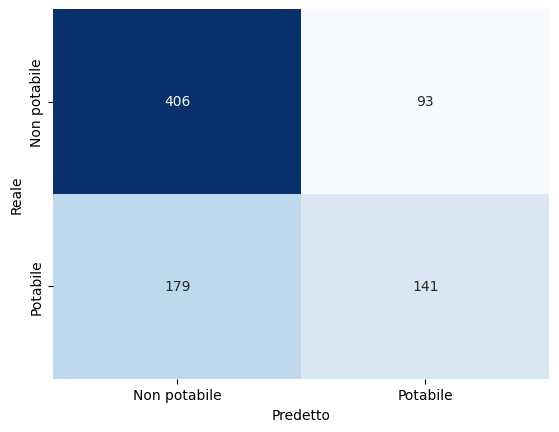

In [71]:
print(f"=== Random Forest | bilanciamento: {'ON' if BILANCIAMENTO else 'OFF'} ===")
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3, target_names=["Non Potabile", "Potabile"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non potabile', 'Potabile'],
            yticklabels=['Non potabile', 'Potabile'])
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.show()

### XGBoost

In [72]:
# scale_pos_weight: analogo di class_weight='balanced' per XGBoost (n_negativi / n_positivi)
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(n_estimators=400,
                          random_state=RANDOM_STATE,
                          eval_metric='logloss',
                          n_jobs=-1,
                          scale_pos_weight=spw if BILANCIAMENTO else 1))   # <- leva bilanciamento
])

param_grid_xgb = {
    'clf__n_estimators':     [100, 200, 400, 600],
    'clf__learning_rate':    [0.01, 0.02, 0.03, 0.1],
    'clf__max_depth':        [3, 5, 7, 10],
    'clf__subsample':        [0.8, 1.0],
}

xgb_grid = run_grid_search(xgb_pipe, param_grid_xgb, scoring='f1_macro')

Combinazioni provate: 128
Miglior f1_macro (CV): 0.638
Migliori parametri:
  clf__learning_rate: 0.02
  clf__max_depth: 10
  clf__n_estimators: 100
  clf__subsample: 0.8


In [73]:
best_xgb = xgb_grid.best_estimator_
registra_e_confronta('XGBoost', best_xgb, cv_f1=xgb_grid.best_score_)

[XGBoost]  CV_F1 (tuned): 0.638   Train_F1: 0.971   (baseline non tunata -> CV 0.603)


=== XGBoost | bilanciamento: ON ===
              precision    recall  f1-score   support

Non Potabile      0.693     0.760     0.725       499
    Potabile      0.559     0.475     0.514       320

    accuracy                          0.648       819
   macro avg      0.626     0.617     0.619       819
weighted avg      0.640     0.648     0.642       819



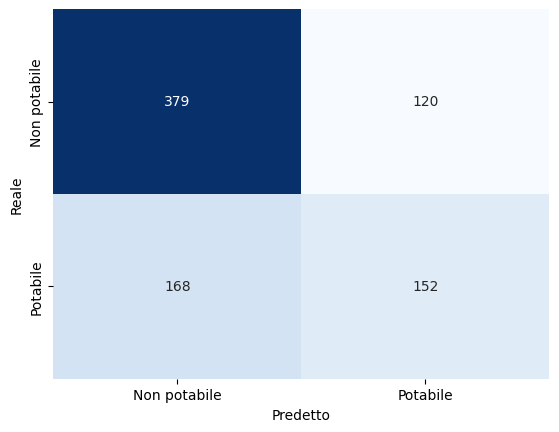

In [74]:
print(f"=== XGBoost | bilanciamento: {'ON' if BILANCIAMENTO else 'OFF'} ===")
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=3, target_names=["Non Potabile", "Potabile"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non potabile', 'Potabile'],
            yticklabels=['Non potabile', 'Potabile'])
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.show()

### SVM RBF

In [75]:
# SVM è sensibile alla scala -> imputazione + RobustScaler
svm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('clf', SVC(kernel='rbf', random_state=RANDOM_STATE,
                class_weight='balanced' if BILANCIAMENTO else None))   # <- leva bilanciamento
])

# C e gamma governano il kernel RBF
param_grid_svm = {
    'clf__C':            [0.1, 1, 10, 100],
    'clf__gamma':        ['scale', 0.01, 0.1, 0.2, 1],
}

svm_grid = run_grid_search(svm_pipe, param_grid_svm, scoring='f1_macro')

Combinazioni provate: 20
Miglior f1_macro (CV): 0.647
Migliori parametri:
  clf__C: 10
  clf__gamma: 0.1


In [76]:
best_svm = svm_grid.best_estimator_
registra_e_confronta('SVM RBF', best_svm, cv_f1=svm_grid.best_score_)

[SVM RBF]  CV_F1 (tuned): 0.647   Train_F1: 0.780   (baseline non tunata -> CV 0.601)


=== SVM RBF | bilanciamento: ON ===
              precision    recall  f1-score   support

Non Potabile      0.685     0.713     0.699       499
    Potabile      0.522     0.487     0.504       320

    accuracy                          0.625       819
   macro avg      0.603     0.600     0.601       819
weighted avg      0.621     0.625     0.623       819



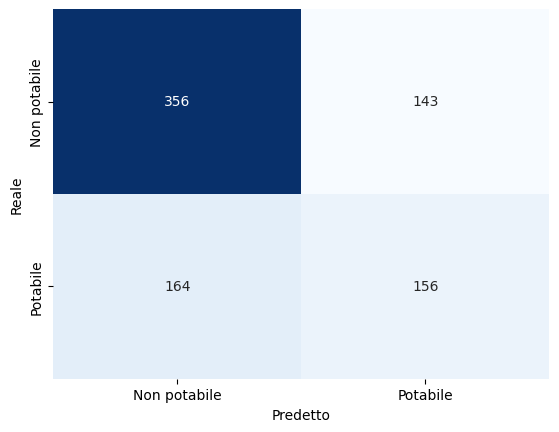

In [77]:
print(f"=== SVM RBF | bilanciamento: {'ON' if BILANCIAMENTO else 'OFF'} ===")
y_pred = best_svm.predict(X_test)
print(classification_report(y_test, y_pred, digits=3, target_names=["Non Potabile", "Potabile"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non potabile', 'Potabile'],
            yticklabels=['Non potabile', 'Potabile'])
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.show()

### MLP

In [78]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
]
if BILANCIAMENTO:
    steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))   # <- leva bilanciamento
steps.append(('clf', MLPClassifier(random_state=RANDOM_STATE, max_iter=500)))

mlp_pipe = ImbPipeline(steps)

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(50,), (100,), (128, 64), (64, 32)],
    'clf__activation':         ['relu', 'tanh'],
    'clf__alpha':              [0.001, 0.01, 0.1, 1.0],
    'clf__learning_rate_init': [0.0005, 0.001, 0.01],
    'clf__early_stopping':     [True],
}

mlp_grid = run_grid_search(mlp_pipe, param_grid_mlp, scoring='f1_macro')

Combinazioni provate: 96
Miglior f1_macro (CV): 0.641
Migliori parametri:
  clf__activation: relu
  clf__alpha: 0.001
  clf__early_stopping: True
  clf__hidden_layer_sizes: (128, 64)
  clf__learning_rate_init: 0.001


In [79]:
best_mlp = mlp_grid.best_estimator_
registra_e_confronta('MLP (sklearn)', best_mlp, cv_f1=mlp_grid.best_score_)

[MLP (sklearn)]  CV_F1 (tuned): 0.641   Train_F1: 0.760   (baseline non tunata -> CV 0.634)


=== MLP (sklearn) | bilanciamento: ON ===
              precision    recall  f1-score   support

Non Potabile      0.683     0.661     0.672       499
    Potabile      0.497     0.522     0.509       320

    accuracy                          0.607       819
   macro avg      0.590     0.592     0.591       819
weighted avg      0.610     0.607     0.608       819



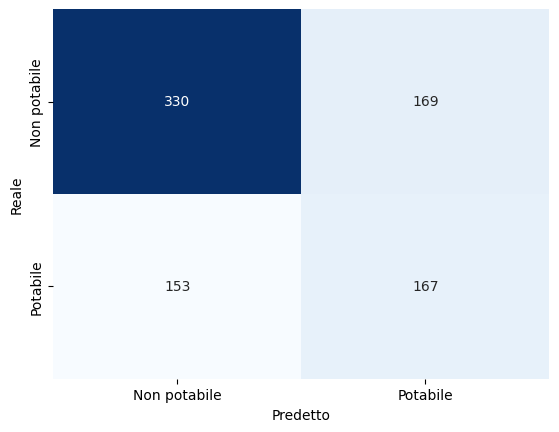

In [80]:
print(f"=== MLP (sklearn) | bilanciamento: {'ON' if BILANCIAMENTO else 'OFF'} ===")
y_pred = best_mlp.predict(X_test)
print(classification_report(y_test, y_pred, digits=3, target_names=["Non Potabile", "Potabile"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non potabile', 'Potabile'],
            yticklabels=['Non potabile', 'Potabile'])
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.show()

### Rete neurale (Keras + Optuna)

La rete viene ottimizzata con **Optuna** usando lo **stesso protocollo** dei modelli classici: l'objective massimizza l'**F1 macro in 5-fold cross-validation sul solo training**.



In [81]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def pesi_classe(y):
    """Dizionario di class_weight 'balanced' calcolato sul solo y passato (fold di train)."""
    cls = np.unique(y)
    w = compute_class_weight('balanced', classes=cls, y=y)
    return {int(c): float(wi) for c, wi in zip(cls, w)}

def costruisci_rete(input_dim, n_layers, units, dropout, lr):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for _ in range(n_layers):
        model.add(keras.layers.Dense(units, activation='relu'))
        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units    = trial.suggest_categorical('units', [16, 32, 64, 128])
    dropout  = trial.suggest_float('dropout', 0.0, 0.4, step=0.1)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epochs   = trial.suggest_categorical('epochs', [50, 100])
    batch    = trial.suggest_categorical('batch_size', [32, 64])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1s = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        # preprocessing fittato SOLO sul fold di train -> nessun leakage tra i fold
        imp, sca = SimpleImputer(strategy='median'), RobustScaler()
        X_tr_s  = sca.fit_transform(imp.fit_transform(X_tr))
        X_val_s = sca.transform(imp.transform(X_val))

        cw = pesi_classe(y_tr) if BILANCIAMENTO else None   # <- leva bilanciamento

        tf.keras.utils.set_random_seed(RANDOM_STATE)
        model = costruisci_rete(X_tr_s.shape[1], n_layers, units, dropout, lr)
        model.fit(X_tr_s, y_tr, epochs=epochs, batch_size=batch, verbose=0, class_weight=cw)

        pred = (model.predict(X_val_s, verbose=0).ravel() > 0.5).astype(int)
        f1s.append(f1_score(y_val, pred, average='macro'))
        keras.backend.clear_session()
    return float(np.mean(f1s))

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
# n_trials riducibile (es. 15-20) se Colab va in timeout
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nMiglior CV F1 macro (rete | bilanciamento {'ON' if BILANCIAMENTO else 'OFF'}): {study.best_value:.3f}")
print("Migliori iperparametri:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Miglior CV F1 macro (rete | bilanciamento ON): 0.637
Migliori iperparametri:
  n_layers: 3
  units: 128
  dropout: 0.30000000000000004
  lr: 0.0013332363056676084
  epochs: 100
  batch_size: 64


In [82]:
# Riallenamento della rete migliore su tutto il training .
bp = study.best_params

keras_imputer = SimpleImputer(strategy='median')
keras_scaler  = RobustScaler()
X_train_keras = keras_scaler.fit_transform(keras_imputer.fit_transform(X_train))

cw = pesi_classe(y_train) if BILANCIAMENTO else None

tf.keras.utils.set_random_seed(RANDOM_STATE)
keras_best = costruisci_rete(X_train_keras.shape[1], bp['n_layers'], bp['units'],
                             bp['dropout'], bp['lr'])
keras_best.fit(X_train_keras, y_train, epochs=bp['epochs'],
               batch_size=bp['batch_size'], verbose=0, class_weight=cw)

def predici_keras(X):
    Xs = keras_scaler.transform(keras_imputer.transform(X))
    return (keras_best.predict(Xs, verbose=0).ravel() > 0.5).astype(int)

registra_e_confronta('Rete neurale (Keras)', cv_f1=study.best_value, predict_fn=predici_keras)

[Rete neurale (Keras)]  CV_F1 (tuned): 0.637   Train_F1: 0.887


=== Rete neurale (Keras) | bilanciamento: ON ===
              precision    recall  f1-score   support

Non Potabile      0.688     0.697     0.693       499
    Potabile      0.518     0.506     0.512       320

    accuracy                          0.623       819
   macro avg      0.603     0.602     0.602       819
weighted avg      0.621     0.623     0.622       819



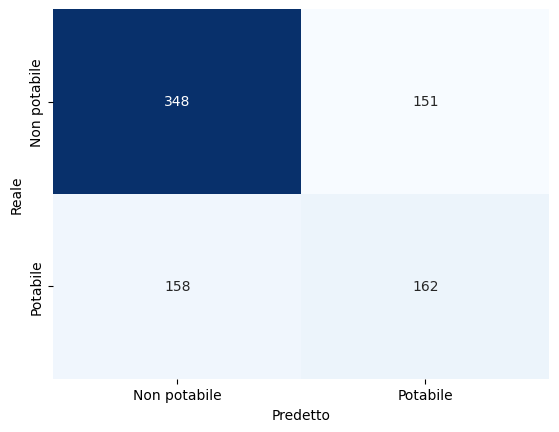

In [83]:
print(f"=== Rete neurale (Keras) | bilanciamento: {'ON' if BILANCIAMENTO else 'OFF'} ===")
y_pred = predici_keras(X_test)
print(classification_report(y_test, y_pred, digits=3, target_names=["Non Potabile", "Potabile"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non potabile', 'Potabile'],
            yticklabels=['Non potabile', 'Potabile'])
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.show()

## Confronto finale: validation (CV) vs test

Per ogni metodo ottimizzato confrontiamo le prestazioni su **validation** (`CV_F1`) e su **test** (`Test_F1`, `Test_Acc`).



In [87]:
rows = []
for n, d in tuned_models.items():
    y_pred  = d['predict'](X_test)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    rows.append({
        'Model':       n,
        'CV_F1':       d['cv_f1'],                 # validation: F1 macro in 5-fold CV sul train
        'Test_F1':     test_f1,                    # test: F1 macro
        'Test_Acc':    accuracy_score(y_test, y_pred),
        'Train_F1':    d['train_f1'],              # spia di overfitting
    })

final_df = (pd.DataFrame(rows)
            .sort_values('CV_F1', ascending=False)
            .reset_index(drop=True))

display(final_df.round(3))


,Model,CV_F1,Test_F1,Test_Acc,Train_F1
0,SVM RBF,0.647,0.601,0.625,0.780
1,MLP (sklearn),0.641,0.591,0.607,0.760
2,XGBoost,0.638,0.619,0.648,0.971
3,Rete neurale (Keras),0.637,0.602,0.623,0.887
4,Random Forest,0.632,0.629,0.668,0.939


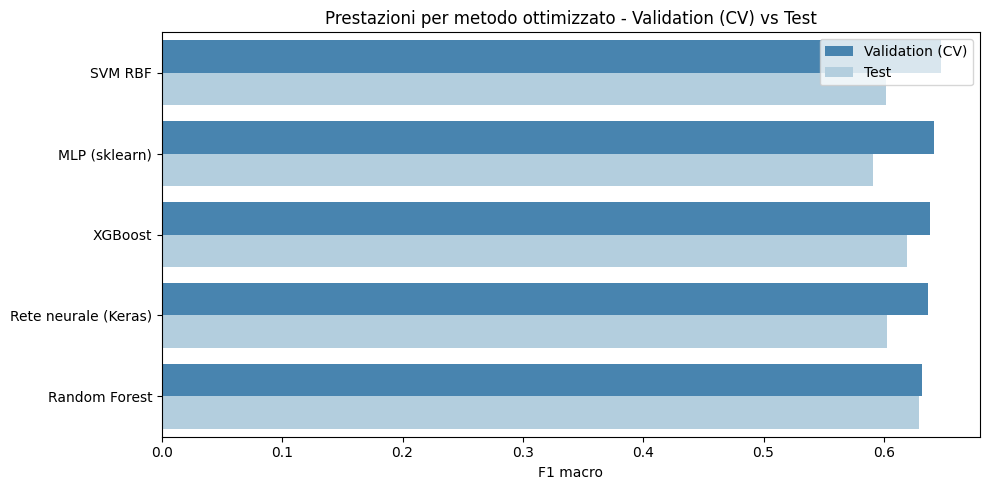

In [89]:
plot_long = final_df.melt(id_vars='Model', value_vars=['CV_F1', 'Test_F1'],
                          var_name='Set', value_name='F1_macro')
plot_long['Set'] = plot_long['Set'].map({'CV_F1': 'Validation (CV)', 'Test_F1': 'Test'})

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_long, y='Model', x='F1_macro', hue='Set', palette='Blues_r')
plt.title('Prestazioni per metodo ottimizzato - Validation (CV) vs Test')
plt.xlabel('F1 macro'); plt.ylabel('')
plt.legend(title=''); plt.tight_layout(); plt.show()